# Toilet Reference Matching with OpenCV

# Load Libraries

In [ ]:
import cv2 as cv
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from utils import match_ref_get_roi, match_ref_get_match

## Hole Matching

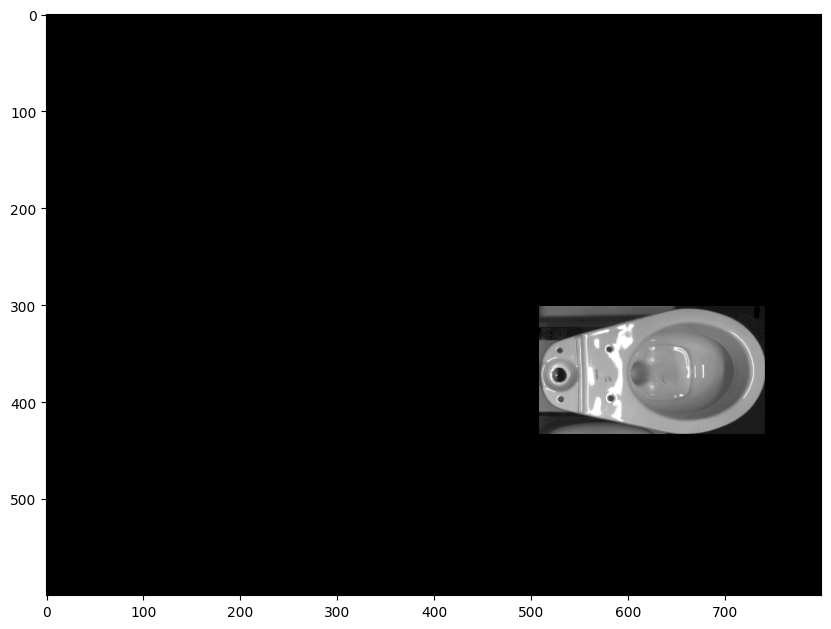

In [2]:
img = cv.imread('ej_mascara_ref_match_der.png', cv.IMREAD_GRAYSCALE)

fig = plt.figure(figsize=(10, 8))
plt.imshow(img, cmap="gray")

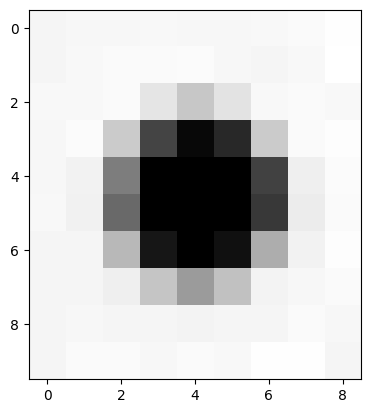

In [3]:
templateHole = cv.imread('Ref_Hole.png', 0)
wt, ht = templateHole.shape[::-1]

plt.imshow(templateHole, cmap="gray")

In [ ]:
# derecha
x1=507
y1=301
x2=742
y2=434
centro_x = (x2 + x1) // 2

# izquierda
# x1= 58
# y1= 309
# x2= 309
# y2= 443
# centro_x = (x2 - x1) // 2

### ROI

(<Axes: >, <matplotlib.image.AxesImage at 0x1c70c23eb30>)

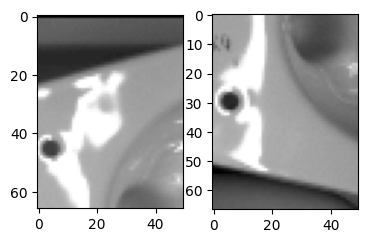

In [5]:
roi_top, roi_bottom, _ = match_ref_get_roi(img, x1,y1,x2,y2,centro_x)
plt.subplot(131),plt.imshow(roi_top, cmap='gray')
plt.subplot(132),plt.imshow(roi_bottom, cmap="gray")

#### Match

**Matching Hole 1**

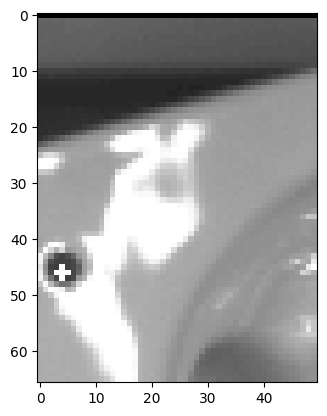

In [6]:
pos_ref_top, top_finded = match_ref_get_match(roi_top)
match_roi_top = cv.circle(roi_top, (pos_ref_top[0], pos_ref_top[1]), radius=0, color=(255, 255, 255), thickness=2)
plt.imshow(roi_top, cmap="gray")

**Matching Hole 2**

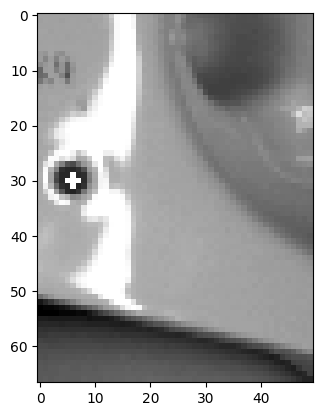

In [7]:
pos_ref_bottom, bottom_finded = match_ref_get_match(roi_bottom)
match_roi_top = cv.circle(roi_bottom, (pos_ref_bottom[0], pos_ref_bottom[1]), radius=0, color=(255, 255, 255), thickness=2)
plt.imshow(roi_bottom, cmap="gray")

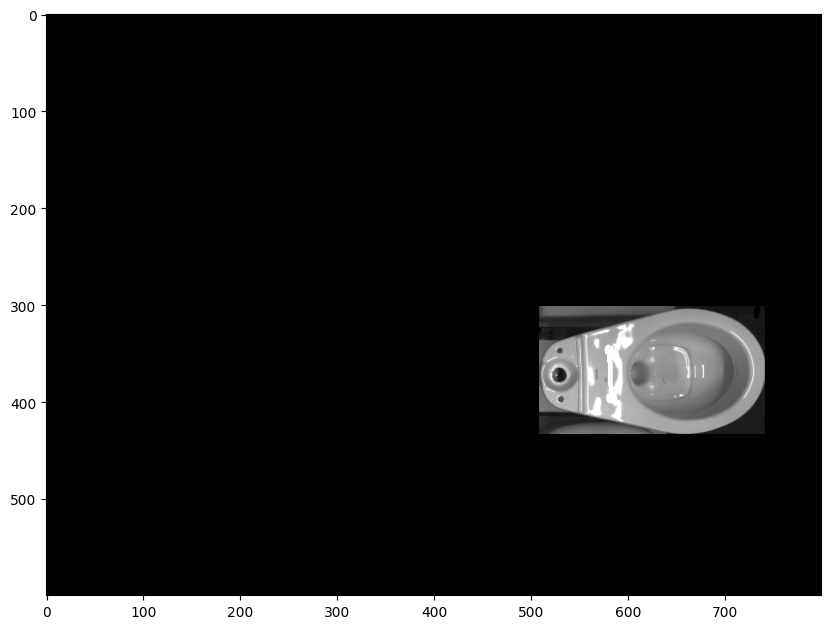

In [8]:
mid_crop = (y2 - y1) // 2
img = cv.circle(img, (x1+70+pos_ref_top[0], y1+pos_ref_top[1]), radius=0, color=(255, 255, 255), thickness=10)
img = cv.circle(img, (x1+70+pos_ref_bottom[0], y1+mid_crop+pos_ref_bottom[1]), radius=0, color=(255, 255, 255), thickness=10)
img = cv.line(img, (pos_ref_top[0] + x1+70, pos_ref_top[1] + y1), (pos_ref_bottom[0] + x1 +70, pos_ref_bottom[1] + y1 + mid_crop), (255, 255, 255), 3)

# Visualize matching
fig = plt.figure(figsize=(10, 8))
plt.imshow(img, cmap='gray')

In [9]:
# distance_pixel si no se encuentra match
distance_pixel = 50
distance_mm = 150

# if ambos huecos -> calcular distancia
if top_finded and bottom_finded:
    distance_pixel = math.dist((x1 + 70 + pos_ref_top[0], y1 + pos_ref_top[1]),
                                (x1 + 70 + pos_ref_bottom[0], y1 + mid_crop + pos_ref_bottom[1]))
    print('distancia en pixel: ', distance_pixel)

relacion_pixel_mm = distance_pixel / distance_mm

print(relacion_pixel_mm)

distancia en pixel:  50.039984012787215
0.33359989341858143
